# **SED CALIB**

## **0. Initialisation**

### 0.1 Packages

In [1]:
### Libs ###
from imports import *

#custom
from src.download_bt_spectra import download_bt_spectra
import src.data_manipulations as dm; reload(dm)
import src.plot_tools as pt; reload(pt)
import src.photometry_errors as pe; reload(pe)
from src.format_to_dat import format_to_lephareinput 

#lephare
import lephare as lp
config = lp.default_stargal_config.copy()

base_dir = os.path.abspath(os.path.join(os.getcwd()))
sys.path.append(base_dir)

%matplotlib inline

LEPHAREDIR is being set to the default cache directory:
/home/hallouin/.cache/lephare/data
More than 1Gb may be written there.
LEPHAREWORK is being set to the default cache directory:
/home/hallouin/.cache/lephare/work
Default work cache is already linked. 
This is linked to the run directory:
/home/hallouin/.cache/lephare/runs/20251013T115331


### 0.2 Download spectra

Use ``download_bt_spectra.py``

In [2]:
#--- Downloading parameters--- 
#model
MODEL = "bt-nextgen-agss2009"
BASE_URL = f"https://svo2.cab.inta-csic.es/theory/newov2/ssap.php?model={MODEL}"

#physical quantities
teff_values = 40000
logg_values = 4
metallicity_values = 0

#dl directory
sed_name = f"Teff{teff_values}logg{logg_values}feh{metallicity_values}"
local_dir = f'data/tests/bt_spectra_{sed_name}'
OUTPUT_DIR = os.path.abspath(os.path.join(base_dir, local_dir))
#Control wavelength range and resolution
LMIN = 1145.0   # Å, set to None to keep full range
LMAX = 25005.0  # Å
DL   = 5.0      # Å, set to None to keep original sampling
wl_norm = 10000 # Å
make_sed_list = True # create sed list in the same folder
overwrite_seds = False # if true, overwrite identically named seds
list_name = f"bt_star_sed_{sed_name}"

#--- Download ---
download_bt_spectra(
    MODEL = MODEL,
    BASE_URL = BASE_URL,
    OUTPUT_DIR = OUTPUT_DIR,
    teff_values = teff_values,
    logg_values = logg_values,
    metallicity_values = metallicity_values,
    LMIN = LMIN,
    LMAX = LMAX,
    DL   = DL,
    wl_norm = wl_norm,
    make_sed_list = make_sed_list,
    overwrite_seds = overwrite_seds,
    list_name = list_name,)

13627 <TR> lines found in VOTABLE.
1 spectra found matching with the chosen grid.
/home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff40000logg4feh0/Teff40000_logg4.0_FeH0.0.sed
All available spectrum have been downloaded and formated.


### 0.3 Other important inputs

In [3]:
n_sources = 10000 # Number of sources to sample
max_row_lephare = 10000 # Number of rows to loop on when zphota

## **1. Run first LePHARE steps**

### 1.1 Sed to Lib

In [4]:
#--- With BT ---
SED_list_path = f"{base_dir}/{local_dir}/{list_name}.list"
sedLib = lp.Sedtolib(config_keymap={
    "STAR_SED": lp.keyword("STAR_SED", SED_list_path),
    "STAR_FSCALE": lp.keyword("STAR_FSCALE", "1.0"),
    "STAR_LIB": lp.keyword("STAR_LIB", f'BT_SEDs_{sed_name}')},)
    
sedLib.run(typ="S")

#######################################
# It s translating SEDs to binary library #
# with the following options :           
# Config file     : 
# Library type     : STAR
# STAR_SED    :/home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff40000logg4feh0/bt_star_sed_Teff40000logg4feh0.list
# STAR_LIB    :BT_SEDs_Teff40000logg4feh0
# STAR_LIB doc:/home/hallouin/.cache/lephare/work/lib_bin/BT_SEDs_Teff40000logg4feh0.doc
# STAR_FSCALE :1
#######################################
Number of SED in the list 1


### 1.1 MagGal

In [5]:
maglib = lp.MagGal(config_keymap=lp.all_types_to_keymap(config))

star_lib_in = f"BT_SEDs_{sed_name}"
star_lib_out = f"BT_LSST_{sed_name}"
maglib.run(typ="S",
    star_lib_in=star_lib_in,
    star_lib_out=star_lib_out,
    filter_file="photozdc1",
    magtype="AB",
    mod_extinc="0",
    extinc_law="calzetti.dat",
    em_dispersion="0",
    lib_ascii="YES",
    z_step="0.0,0,0")

#######################################
# It s computing the SYNTHETIC MAGNITUDES #
# For Gal/QSO libraries with these OPTIONS #
# with the following options :           
# Config file     : 
# Filter file     : photozdc1
# Magnitude type     : AB
# COSMOLOGY   :70,0.3,0.7
# STAR_LIB_IN    :/home/hallouin/.cache/lephare/work/lib_bin/BT_SEDs_Teff40000logg4feh0(.doc & .bin)
# STAR_LIB_OUT   :/home/hallouin/.cache/lephare/work/lib_mag/BT_LSST_Teff40000logg4feh0(.doc & .bin)
# LIB_ASCII   YES
# CREATION_DATE Fri Mar 20 10:32:20 2026
#############################################


## **2. Make mock catalog from mag lib**

### 2.1 Load magbin into pandas and sed physical data

In [6]:
#--- copy-paste maglib from the lepahre cache folder ---
from pathlib import Path
import shutil
cache_dir = Path.home() / f".cache/lephare/work/lib_mag/{star_lib_out}.dat"
paste_path = f"{base_dir}/{local_dir}/"
shutil.copy(cache_dir, paste_path)  # copie simple

'/home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff40000logg4feh0/BT_LSST_Teff40000logg4feh0.dat'

In [7]:
maglib = dm.maglib_to_pandas(f"{base_dir}/{local_dir}/{star_lib_out}.dat")

In [8]:
class SED_GRID:
    '''
    For a SED set dependent on physical parameters, construct a coherent grid.
    '''
    def __init__(self, list_path):
        """Load SED list."""
        sed_list = []
        with open(list_path, 'r') as file:
            for line in file:
                line = line.strip()
                if line.startswith('#') or not line:
                    continue
                filepath = line.split()[0]
                sp_type = filepath.split('/')[-1].replace('.sed', "")
                sed_list.append(sp_type)
        self.sed_list = sed_list
        self.sed_grid = None

    def build(self):
        """Build the sed grid [Id, Teff, logg, FeH] from filenames."""
        pattern = r"Teff([-\d\.]+)_logg([-\d\.]+)_FeH([-\d\.]+)"
        sed_grid = []
        for Id, s in enumerate(self.sed_list):
            match = re.search(pattern, s)
            if match:
                Teff, logg, FeH = match.groups()
                Teff, logg, FeH = float(Teff), float(logg), float(FeH)
                sed_grid.append([Id, Teff, logg, FeH])
        self.sed_grid = np.array(sed_grid)
        return self.sed_grid

sed_grid_path = f'{base_dir}/{local_dir}/{list_name}.list'
sed_grid_init = SED_GRID(sed_grid_path)
sed_grid = sed_grid_init.build()
sed_grid[:,0] = sed_grid[:,0] + 1
sed_grid = pd.DataFrame(sed_grid, columns=["model", "teff", "logg", "feh"])

In [9]:
maglib = dm.join_tables(maglib, (sed_grid, "model", "model"))
maglib

,model,N_filt,magnitude_u,magnitude_g,magnitude_r,magnitude_i,magnitude_z,magnitude_y,teff,logg,feh
0,1.0,6.0,-24.2181,-23.8782,-23.3686,-22.9782,-22.6808,-22.4661,40000.0,4.0,0.0


### 2.2 Generate sources

In [10]:
class MockPhotometry:        
    @staticmethod
    def generate_sources_from_magabs(mags, ref_index, mag_min, mag_max, N, method="uniform"):
        """
        Generates N sources from a SED in magnitudes, with the reference band
        uniformly distributed between mag_min and mag_max. The other bands are
        shifted to preserve colors.
        """
        mags = np.array(mags)
        Nband = len(mags)
        
        if method == 'uniform':
            ref_mags = np.random.uniform(low=mag_min, high=mag_max, size=N)
            delta_M = ref_mags - mags[ref_index]
            sources = mags[None, :] + delta_M[:, None]
        else:
            raise NotImplementedError(f"Method '{method}' not implemented yet")
        
        return sources

    @staticmethod
    def generate_sources_from_table(table, mag_cols, ref_index, mag_min, mag_max, N_per_star, method="uniform", return_full_table=False):
        """
        Generates mock sources from a Pandas table for each source.
        """
        mock_list = []

        mock_list = []

        for _, row in table.iterrows():
            mags = row[mag_cols].values
            sources = MockPhotometry.generate_sources_from_magabs(mags, ref_index, mag_min, mag_max, N_per_star, method)

            df_sources = pd.DataFrame(sources, columns=mag_cols)

            if return_full_table:
                # dupliquer les autres colonnes
                other_cols = row.drop(labels=mag_cols)
                df_other = pd.DataFrame([other_cols.values]*N_per_star, columns=other_cols.index)

                df_sources = pd.concat([df_other.reset_index(drop=True),
                                        df_sources.reset_index(drop=True)],
                                        axis=1)

            mock_list.append(df_sources)

        df_mock = pd.concat(mock_list, ignore_index=True)
        return df_mock
    
    @staticmethod
    def generate_errors(table, mag_columns, models=None, model_names=None, suffix="_err_sim", error_cut=None,
                random_state=None, format="MMEE", add_errors=True, keep_true_mags=True, default_error_value=None):
        """ 
        Generate photometric errors using PhotometricErrorModel and optionally
        add Gaussian noise to magnitudes.
        """

        if default_error_value is not None:
            table_with_errs = table.copy()
            for col in mag_columns:
                table_with_errs[col + suffix] = np.full(len(table_with_errs), default_error_value)
                
            if add_errors:
                #sample noisy cols
                rng = np.random.default_rng(random_state)
                mags = table_with_errs[mag_columns].to_numpy(dtype=float)
                err_cols = [c + suffix for c in mag_columns]
                sigmas = table_with_errs[err_cols].to_numpy(dtype=float)
                noise = rng.normal(loc=0.0, scale=sigmas)
                mags_obs = mags + noise
                #add to table
                table_with_errs[mag_columns] = mags_obs
                table_with_errs[err_cols] = sigmas

            if keep_true_mags:
                true_cols = [c + "_true" for c in mag_columns]
                table_with_errs[true_cols] = mags

            return table_with_errs

        # Generate errors
        table_with_errs = pe.PhotometricErrorModel().sample_errors_on_catalog(
            table, mag_columns=mag_columns, models=models, model_names=model_names, format=format)

        if not add_errors:
            return table_with_errs

        rng = np.random.default_rng(random_state)

        # Numpy vectorisation
        mags = table_with_errs[mag_columns].to_numpy(dtype=float)
        err_cols = [c + suffix for c in mag_columns]
        sigmas = table_with_errs[err_cols].to_numpy(dtype=float)
        # Gaussian noise
        noise = rng.normal(loc=0.0, scale=sigmas)

        mags_obs = mags + noise

        if error_cut is not None:
            mask_low_snr = error_cut < sigmas
            mags_obs[mask_low_snr] = np.nan
            sigmas[mask_low_snr] = np.nan

        if keep_true_mags:
            true_cols = [c + "_true" for c in mag_columns]
            table_with_errs[true_cols] = mags

        table_with_errs[mag_columns] = mags_obs
        table_with_errs[err_cols] = sigmas

        return table_with_errs

In [11]:
mock_mags = MockPhotometry.generate_sources_from_table(table=maglib,
    mag_cols=['magnitude_u','magnitude_g','magnitude_r','magnitude_i','magnitude_z','magnitude_y'],
    ref_index=2,
    mag_min=17.5,
    mag_max=26.5,
    N_per_star=n_sources,
    method='uniform',
    return_full_table=True)

In [12]:
# pt.plot_histograms(mock_mags, ["magnitude_u", "magnitude_g", "magnitude_r", "magnitude_y"], alpha=0.6, edgecolor="k")

### 2.3 Generate errors and observed mags

In [13]:
dp1_ECDFS = pd.read_csv(f"{base_dir}/data/catalogs/DP1_ECDFS_photometry.csv")
dp1_ECDFS = dp1_ECDFS[(dp1_ECDFS["u_cModelMag"]<26.5) & (dp1_ECDFS["g_cModelMag"]<26.5) & (dp1_ECDFS["r_cModelMag"]<26.5) 
                        & (dp1_ECDFS["i_cModelMag"]<26.5) & (dp1_ECDFS["z_cModelMag"]<26.5) & (dp1_ECDFS["y_cModelMag"]<26.5)]

Make error model

In [14]:
pem_dp1_ECDFS = pe.PhotometricErrorModel()

dp1_ECDFS_models = pem_dp1_ECDFS.model_collection(x_lists=dp1_ECDFS[["u_cModelMag","g_cModelMag","r_cModelMag","i_cModelMag","z_cModelMag","y_cModelMag"]], 
    sigma_lists=dp1_ECDFS[["u_cModelMagErr","g_cModelMagErr","r_cModelMagErr","i_cModelMagErr","z_cModelMagErr","y_cModelMagErr"]], 
    model_names=["u", "g", "r", "i", "z", "y"],
    sharpness_factor=1.05,
    delta_mag=0.005,
    min_per_bin=None,
    polyfit_deg=4)


/home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/src/photometry_errors.py:194: UserWarning: fit_ends is True and npoints < min_per_bin in the last bins. This can lead to unexpected behavior.
  warnings.warn("fit_ends is True and npoints < min_per_bin in the last bins. This can lead to unexpected behavior.")


Apply

In [15]:
mock_cat = MockPhotometry.generate_errors(mock_mags,
        mag_columns = ['magnitude_u','magnitude_g','magnitude_r','magnitude_i','magnitude_z','magnitude_y'],
        models = dp1_ECDFS_models,
        model_names = ["u", "g", "r", "i", "z", "y"],
        format="MEME",
        error_cut=5,
        default_error_value=None,
        add_errors=True)

Optional: Revert to absolute magnitudes

In [16]:
mock_cat

,model,N_filt,teff,logg,feh,magnitude_u,magnitude_u_err_sim,magnitude_g,magnitude_g_err_sim,magnitude_r,...,magnitude_z,magnitude_z_err_sim,magnitude_y,magnitude_y_err_sim,magnitude_u_true,magnitude_g_true,magnitude_r_true,magnitude_i_true,magnitude_z_true,magnitude_y_true
0,1.0,6.0,40000.0,4.0,0.0,21.211860,0.087965,21.546184,0.003437,22.056219,...,22.756549,0.025486,22.553372,0.206752,21.206894,21.546794,22.056394,22.446794,22.744194,22.958894
1,1.0,6.0,40000.0,4.0,0.0,25.051398,0.329593,25.394074,0.041357,25.979757,...,27.226599,0.614131,NaN,NaN,25.088217,25.428117,25.937717,26.328117,26.625517,26.840217
2,1.0,6.0,40000.0,4.0,0.0,21.483420,0.014305,21.822528,0.003395,22.337819,...,23.044117,0.055297,23.070574,0.379150,21.480458,21.820358,22.329958,22.720358,23.017758,23.232458
3,1.0,6.0,40000.0,4.0,0.0,22.779589,0.046758,23.263141,0.013423,23.752705,...,24.520049,0.144367,26.166577,1.263845,22.917816,23.257716,23.767316,24.157716,24.455116,24.669816
4,1.0,6.0,40000.0,4.0,0.0,25.190753,0.625261,25.856238,0.078398,26.317293,...,27.428290,0.778763,NaN,NaN,25.514577,25.854477,26.364077,26.754477,27.051877,27.266577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.0,6.0,40000.0,4.0,0.0,17.430032,0.002783,17.767453,0.000683,18.273949,...,18.964656,0.003474,19.259818,0.054077,17.427362,17.767262,18.276862,18.667262,18.964662,19.179362
9996,1.0,6.0,40000.0,4.0,0.0,21.077482,0.017759,21.404307,0.014152,21.911386,...,22.633024,0.019604,22.754560,0.178600,21.061634,21.401534,21.911134,22.301534,22.598934,22.813634
9997,1.0,6.0,40000.0,4.0,0.0,18.924537,0.031790,19.276154,0.001547,19.787020,...,20.471128,0.003390,20.646756,0.141967,18.936406,19.276306,19.785906,20.176306,20.473706,20.688406
9998,1.0,6.0,40000.0,4.0,0.0,19.531037,0.004780,19.867713,0.001771,20.382215,...,21.101801,0.023920,21.299304,0.030776,19.528320,19.868220,20.377820,20.768220,21.065620,21.280320


In [17]:
mock_cat.to_csv(f"{base_dir}/{local_dir}/{sed_name}_mock.csv", index=False)

## 3. **zphota**

### 3.1 Convert mock to lephare input

In [18]:
#--- Run if no Ids in your table ---
def add_ids(df, base_id):
    n = len(df)
    width = len(str(n-1))
    df.insert(0, "mock_id", 0)
    df["mock_id"] = str(base_id) + pd.Series(range(n)).astype(str).str.zfill(width)
    
    return df

cat_path = f"{base_dir}/{local_dir}/{sed_name}_mock.csv"
temp = pd.read_csv(cat_path)
temp = add_ids(temp, 123456)
temp.to_csv(cat_path, index=False)

In [19]:
csv_in = f"{base_dir}/{local_dir}/{sed_name}_mock.csv"
dat_out = f"{base_dir}/{local_dir}/{sed_name}_mock.dat"

input_columns = ['mock_id', 
    'magnitude_u', 'magnitude_g', 'magnitude_r', 'magnitude_i', 'magnitude_z', 'magnitude_y',
    'magnitude_u_err_sim', 'magnitude_g_err_sim', 'magnitude_r_err_sim', 'magnitude_i_err_sim', 'magnitude_z_err_sim', 'magnitude_y_err_sim']

format_to_lephareinput(CAT_IN=csv_in,
    CAT_OUT=dat_out,
    input_columns=input_columns,
    n_filters=6,
    CAT_TYPE='long',
    simple_convert=False,
    apply_context = 'yes',
    facticious_specz = 0.,
    shuffle=False,
    max_rows=None,
    error_value_state='default')

[INFO] Added missing 'context' column automatically.
[INFO] Replacing 2246 missing values with 99.0
[INFO] Added constant spec-z column with value 0.0
[OK] Catalog saved → /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff40000logg4feh0/Teff40000logg4feh0_mock.dat


### 3.2 Prepare

In [20]:
f"{base_dir}/{local_dir}/{sed_name}_mock.out"

'/home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff40000logg4feh0/Teff40000logg4feh0_mock.out'

In [21]:
config.update(
    {
        "ZPHOTLIB": f"BT_LSST_{sed_name}",
        "SPEC_OUT": "NO",
        "CAT_IN": dat_out,
        "INP_TYPE": "M",
        "CAT_TYPE": "LONG",
        "CAT_MAG": "AB",
        "PARA_OUT": f"{base_dir}/data/stargal_output.para",
        "CAT_OUT": f"{base_dir}/{local_dir}/{sed_name}_mock.out",
        "AUTO_ADAPT": "NO",
        "PDZ_TYPE": "MIN_ZG",
        "CAT_FMT": "MMEE",
        "ERR_SCALE": 0,
        "SPEC_OUT": "NO",
        "CHI2_OUT": "NO",
        "RM_DISCREPENT": 1e9,
    }
)

zphota = lp.PhotoZ(lp.all_types_to_keymap(config))

####################################### 
# PHOTOMETRIC REDSHIFT with OPTIONS   # 
# Config file            : 
# CAT_IN                 : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff40000logg4feh0/Teff40000logg4feh0_mock.dat
# CAT_OUT                : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff40000logg4feh0/Teff40000logg4feh0_mock.out
# CAT_LINES              : 0 1000000000
# PARA_OUT               : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/stargal_output.para
# INP_TYPE               : M
# CAT_FMT[0:MEME 1:MMEE] : 1
# CAT_MAG                : AB
# ZPHOTLIB               : BT_LSST_Teff40000logg4feh0 
# FIR_LIB                : 
# FIR_LMIN               : 7.000000
# FIR_CONT               : -1.000000
# FIR_SCALE              : -1.000000
# FIR_FREESCALE          : YES
# FIR_SUBSTELLAR         : NO
# ERR_SCALE       

### 3.3 RUN

In [25]:
cat = np.loadtxt(dat_out)
id = cat[:, 0]
mag = cat[:, 1:7]
emag = cat[:, 7:13]
context = cat[:, 13]
zspec = cat[:, 14]
srclist = []
for i in range(max_row_lephare):
    oneObj = lp.onesource(i, zphota.gridz)
    oneObj.readsource(str(id[i]), mag[i, :], emag[i, :], int(context[i]), zspec[i], " ")
    zphota.prep_data(oneObj)
    srclist.append(oneObj)

In [26]:
zphota.run_photoz(srclist[:max_row_lephare], [])
final = zphota.build_output_tables(srclist[:max_row_lephare], filename=f"{base_dir}/{local_dir}/{sed_name}_mock.fits")

In [27]:
final[:5]

IDENT,Z_BEST,Z_MED,Z_MODE,CHI_BEST,MOD_BEST,SCALE_BEST,NBAND_USED,Z_SEC,CHI_SEC,MOD_STAR,CHI_STAR,MAG_OBS(),ERR_MAG_OBS(),ZSPEC,MIN_ZG
str12,float64,float64,float64,float64,int64,float64,int64,float64,float64,int64,float64,float64[6],float64[6],float64,float64[2]
1234560000.0,-99.9,-99.9,0.0,1000000000.0,-99,8.9123823241e-313,6,-99.9,-99.0,1,11.05690658460735,21.21186000000001 .. 22.553370000000008,0.08796 .. 0.20674999999999996,0.0,0.0 .. 0.0
1234560001.0,-99.9,-99.9,0.0,1000000000.0,-99,-20.26104417670683,5,-99.9,-99.0,1,2.427230928504663,25.051400000000008 .. 99.0,0.3295900000000001 .. 99.0,0.0,0.0 .. 0.0
1234560002.0,-99.9,-99.9,0.0,1000000000.0,-99,0.0,6,-99.9,-99.0,1,1.6658599705274,21.483420000000006 .. 23.070569999999996,0.01431 .. 0.37915,0.0,0.0 .. 0.0
1234560003.0,-99.9,-99.9,0.0,1000000000.0,-99,0.0,6,-99.9,-99.0,1,15.65476098645323,22.779590000000013 .. 26.166580000000003,0.04676 .. 1.26384,0.0,0.0 .. 0.0
1234560004.0,-99.9,-99.9,0.0,1000000000.0,-99,-20.26104417670683,5,-99.9,-99.0,1,2.77910086867979,25.19075000000002 .. 99.0,0.62526 .. 99.0,0.0,0.0 .. 0.0


## **4. Statistic**

### 4.1 Chi2 Distribution

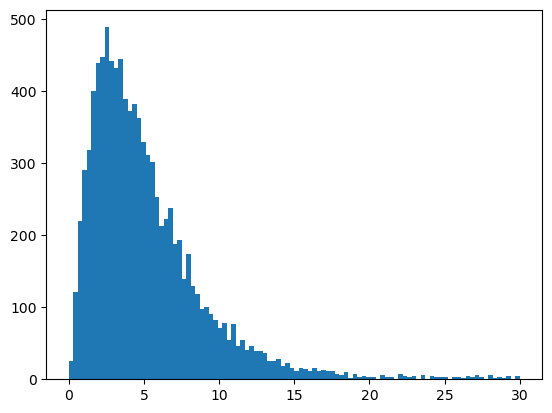

In [28]:
plt.figure()
plt.hist(final["CHI_STAR"], bins=100, range=(0,30))
plt.show()